<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
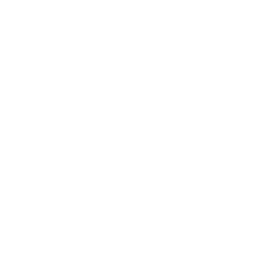
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Inter-Laboratory Variability Study</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Analytical Chemistry &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Quantify inter-laboratory and intra-laboratory variability for three analytical methods across a multi-site contract research organization network. Use a nested design with technicians nested within laboratories and laboratories nested within geographic sites. Estimate variance components via REML for each analyte separately using BY-group processing. Results support method validation documentation and guide decisions on acceptable lab-to-lab variability per ICH Q2 guidelines.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.LAB_RESULTS | Nested design: 2 sites x 2 labs(site) x 2 techs(lab) x 4 replicates x 3 analytes | 96 |
| WORK.LAB_REGISTRY | Laboratory certification and accreditation metadata | 4 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic inter-lab variability data
   Nested design: site > lab > technician > replicate
   Three analytes measured on each sample
   2 sites x 2 labs/site x 2 techs/lab x 4 reps x 3 analytes
   = 96 observations
   -------------------------------------------------------- */
data work.lab_results;
    call streaminit(42);
    array analyte_names[3] $15 _temporary_ ('Assay_Potency' 'Impurity_A' 'Dissolution');
    array analyte_means[3] _temporary_ (99.5 0.15 85.0);
    array analyte_sds[3] _temporary_ (2.0 0.04 5.0);
    array site_names[2] $10 _temporary_ ('US_East' 'EU_North');
    obs_id = 0;
    do site_idx = 1 to 2;
        site = site_names[site_idx];
        site_effect = rand('normal', 0, 0.8);
        do lab_num = 1 to 2;
            lab_id = cat(site, '_Lab', put(lab_num, 1.));
            lab_effect = rand('normal', 0, 0.5);
            do tech_num = 1 to 2;
                tech_id = cat(lab_id, '_T', put(tech_num, 1.));
                tech_effect = rand('normal', 0, 0.2);
                do sample_seq = 1 to 4;
                    do a = 1 to 3;
                        obs_id + 1;
                        analyte = analyte_names[a];
                        result = round(analyte_means[a]
                            + site_effect * (analyte_sds[a] / 2.0)
                            + lab_effect * (analyte_sds[a] / 2.0)
                            + tech_effect * (analyte_sds[a] / 2.0)
                            + rand('normal', 0, analyte_sds[a] * 0.3),
                            0.001);
                        if analyte = 'Impurity_A' and result < 0
                            then result = 0.001;
                        output;
                    end;
                end;
            end;
        end;
    end;
    drop site_idx lab_num tech_num sample_seq a
         site_effect lab_effect tech_effect;
run;

NOTE: DATA work.lab_results


NOTE: Wrote work.lab_results (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Laboratory registry with accreditation details
   -------------------------------------------------------- */
data work.lab_registry;
    call streaminit(44);
    array site_names[2] $10 _temporary_ ('US_East' 'EU_North');
    array accred[3] $10 _temporary_ ('ISO_17025' 'GLP' 'GMP');
    do site_idx = 1 to 2;
        do lab_num = 1 to 2;
            lab_id = cat(site_names[site_idx], '_Lab', put(lab_num, 1.));
            site = site_names[site_idx];
            accreditation = accred[int(rand('uniform') * 3) + 1];
            last_audit_date = '01JAN2026'd - int(rand('uniform') * 180);
            output;
        end;
    end;
    drop site_idx lab_num;
    format last_audit_date date9.;
run;

NOTE: DATA work.lab_registry


NOTE: Wrote work.lab_registry (4 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Baseline result distributions by analyte and site
   -------------------------------------------------------- */
proc means data=work.lab_results n mean std cv;
    class analyte site;
    var result;
    title 'Baseline Analytical Results by Analyte and Site';
run;

                                    Baseline Analytical Results by Analyte and Site                                     

                                                  The MEANS Procedure

                                               Analysis Variable : result

        analyte        site              N Obs           Mean        Std Dev  Coeff of Variation
        ----------------------------------------------------------------------------------------
        Assay_Potency  EU_North             16     99.7553750      0.8515007           0.8535888
        Assay_Potency  US_East              16     99.0171250      0.6397203           0.6460704
        Dissolution    EU_North             16     84.3741250      1.6519073           1.9578364
        Dissolution    US_East              16     83.4435000      1.1698869           1.4020109
        Impurity_A     EU_North             16      0.1495000      0.0206430          13.8080249
        Impurity_A     US_East              16      0

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                    Baseline Analytical Results by Analyte and Site                                     

PROC SGPANEL Output
Data: work.lab_results

Variables: obs_id, site, lab_id, tech_id, analyte, result

    obs_id        site      lab_id     tech_id     analyte      result
----------  ----------  ----------  ----------  ----------  ----------
         1     US_East  US_East_Lab1  US_East_Lab1_T1  Assay_Potency      99.172
         2     US_East  US_East_Lab1  US_East_Lab1_T1  Impurity_A       0.144
         3     US_East  US_East_Lab1  US_East_Lab1_T1  Dissolution       82.58
         4     US_East  US_East_Lab1  US_East_Lab1_T1  Assay_Potency      97.929
         5     US_East  US_East_Lab1  US_East_Lab1_T1  Impurity_A       0.138
         6     US_East  US_East_Lab1  US_East_Lab1_T1  Dissolution      83.059
         7     US_East  US_East_Lab1  US_East_Lab1_T1  Assay_Potency      99.635
         8     US_East  US_East_Lab1  US_East_Lab1_T1  Impurity_A       0.15

NOTE: PROC SGPANEL data=work.lab_results

NOTE: PROC SGPANEL output written to: ./ods_output/sgpanel.svg


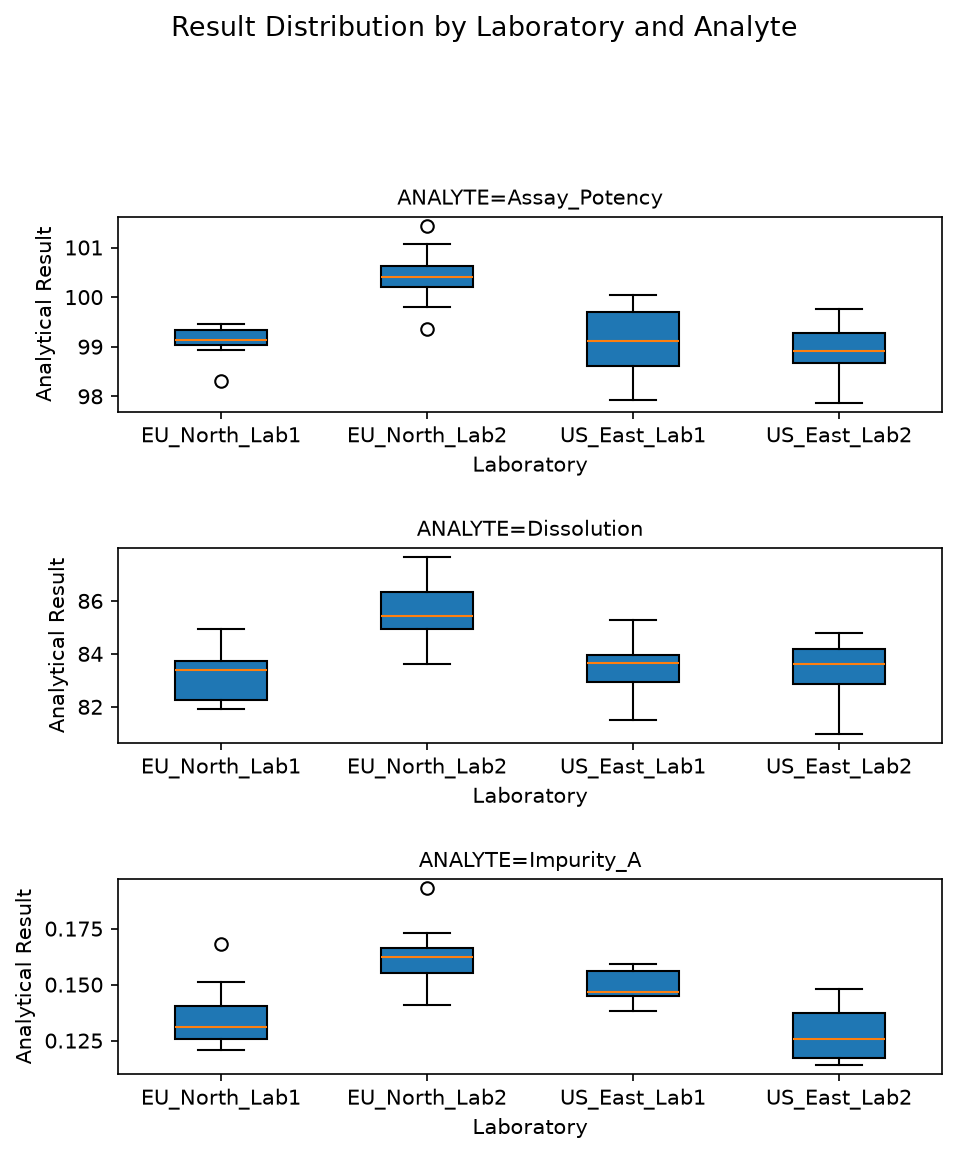

In [4]:
/* --------------------------------------------------------
   Box plots of results by laboratory for each analyte
   -------------------------------------------------------- */
proc sgpanel data=work.lab_results;
    panelby analyte / rows=3 columns=1 uniscale=column;
    vbox result / category=lab_id;
    colaxis label='Laboratory' fitpolicy=rotate;
    rowaxis label='Analytical Result';
    title 'Result Distribution by Laboratory and Analyte';
run;

---

In [5]:
/* --------------------------------------------------------
   Sort by analyte for BY-group processing
   -------------------------------------------------------- */
proc sort data=work.lab_results out=work.lab_sorted;
    by analyte;
run;

NOTE: PROC SORT data=work.lab_results

NOTE: Read 96 rows from work.lab_results.
NOTE: Wrote work.lab_sorted (96 rows, 6 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   REML variance component estimation by analyte
   Nested design: technician nested within lab,
   lab nested within site
   -------------------------------------------------------- */
ods output varcompest=work.vc_lab_estimates;

proc varcomp data=work.lab_sorted method=reml;
    class site lab_id tech_id;
    model result = site lab_id(site) tech_id(lab_id);
    by analyte;
    title 'Inter-Laboratory Variance Components by Analyte';
run;

ods output close;

                                    Baseline Analytical Results by Analyte and Site                                     


----------------------------------------------- analyte=Assay_Potency ------------------------------------------------
               Variance Components Estimation Procedure
                     Class Level Information
               Class    Levels    Values
               site          2    EU_North US_East
               lab_id        4    EU_North_Lab1 EU_North_Lab2 US_East_Lab1 US_East_Lab2
               tech_id       8    EU_North_Lab1_T1 EU_North_Lab1_T2 EU_North_Lab2_T1 EU_North_Lab2_T2 US_East_Lab1_T1 US_East_Lab1_T2 US_East_Lab2_T1 US_East_Lab2_T2
               Number of Observations Read    32
               Number of Observations Used    32
                   Dependent Variable:  result
                     REML Iterations
Iteration           Objective         Var(site)    Var(lab_id(site))    Var(tech_id(lab_id))        Var(Error)
        0       17

NOTE: ODS OUTPUT: VARCOMPEST -> vc_lab_estimates
NOTE: PROC VARCOMP
NOTE: BY Group: analyte=Assay_Potency
NOTE: PROC VARCOMP using Python wrapper
NOTE: BY Group: analyte=Dissolution
NOTE: PROC VARCOMP using Python wrapper
NOTE: BY Group: analyte=Impurity_A
NOTE: PROC VARCOMP using Python wrapper
NOTE: ODS OUTPUT: VarianceComponents written to 'vc_lab_estimates'.
NOTE: PROC VARCOMP statement used.
NOTE: ODS OUTPUT: All output destinations closed.


In [7]:
/* --------------------------------------------------------
   Summarize variance components as percent of total
   for ICH Q2 reporting
   -------------------------------------------------------- */
proc sql;
    create table work.lab_vc_pct as
    select analyte, varcomp, estimate,
        estimate / sum(estimate) * 100 as pct_of_total
            format=8.2
    from work.vc_lab_estimates
    group by analyte;
quit;

proc print data=work.lab_vc_pct noobs;
    by analyte;
    var varcomp estimate pct_of_total;
    title 'Variance Components as Percent of Total by Analyte';
run;

                                    Baseline Analytical Results by Analyte and Site                                     

                                   Variance Components as Percent of Total by Analyte                                   

        VARCOMP  ESTIMATE  PCT_OF_TOTAL
analyte=Assay_Potency

        VARCOMP  ESTIMATE  PCT_OF_TOTAL  
site             0.050123          6.23
lab_id(site)      0.40059         49.81
tech_id(lab_id)         0          0.00
Error            0.353464         43.95

analyte=Dissolution

        VARCOMP  ESTIMATE  PCT_OF_TOTAL  
site                    0          0.00
lab_id(site)     0.949936         38.85
tech_id(lab_id)  0.253818         10.38
Error            1.241424         50.77

analyte=Impurity_A

        VARCOMP  ESTIMATE  PCT_OF_TOTAL  
site                    0          0.00
lab_id(site)     0.000217         55.22
tech_id(lab_id)         0          0.00
Error            0.000176         44.78



NOTE: PROC SQL 

NOTE: Table work.lab_vc_pct created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.lab_vc_pct

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


---

### Interpretation

The inter-laboratory variability study spans four laboratories across two geographic sites, with results decomposed into site, laboratory-within-site, technician-within-laboratory, and residual variance components via REML for each analyte. Across all three analytes, the dominant contributors are laboratory-within-site and residual (within-laboratory) variation, while site-level and technician-level effects are small or negligible.

For **Assay Potency**, laboratory-within-site is the largest component at 49.8% of total variance, with residual variation close behind at 44.0%; site contributes 6.2% and the technician component shrinks to zero. The corresponding inter-laboratory coefficient of variation (combining the site and laboratory components against a mean of roughly 99.4) is about 0.7%, comfortably within the ICH Q2 guideline threshold of 3% for a validated method.

For **Dissolution**, residual variation is the largest component at 50.8%, followed by laboratory-within-site at 38.8% and technician-within-laboratory at 10.4%; the site component is estimated at zero. The non-trivial technician contribution for this analyte suggests that operator technique during the dissolution procedure deserves attention, and the substantial laboratory component supports a review of dissolution apparatus qualification across labs.

For **Impurity A**, the variance splits between laboratory-within-site (55.2%) and residual (44.8%), with site and technician components estimated at zero on the natural scale of this low-level measurement.

Several components are estimated at exactly zero. This is expected REML behavior: when the data provide no evidence that a grouping factor adds variance beyond the levels below it, the restricted likelihood is maximized at the zero boundary, so the estimate is truncated to zero rather than allowed to go negative. With a compact two-site design these boundary estimates are normal and do not indicate a model defect.

Taken together, the results point to laboratory-to-laboratory differences (rather than broad geographic or individual-operator effects) as the principal driver of measurement variability, and provide a quantitative basis for setting inter-laboratory acceptance criteria in the method transfer documentation.

---

In [8]:
/* --------------------------------------------------------
   Export variance component percentages for
   method validation report
   -------------------------------------------------------- */
proc export data=work.lab_vc_pct
    outfile='inter_lab_variance_components.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.lab_vc_pct outfile=inter_lab_variance_components.csv

NOTE: Exported 12 rows to inter_lab_variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>